## Understanding DistilBERT: A Transformer-Based Deep Neural Network

### What is DistilBERT
DistilBERT is a smaller, faster, and lighter variant of BERT (Bidirectional Encoder Representations from Transformers), developed by Hugging Face.  
It was created to reduce computational cost while retaining most of BERT's performance. DistilBERT retains approximately 97% of BERT’s language understanding ability while being 40% smaller and 60% faster.

The model is pre-trained on large-scale English text and fine-tuned for specific tasks such as sentiment analysis, text classification, and question answering.

---

### Model Architecture
- **Base Architecture:** Transformer Encoder (same as BERT)  
- **Number of Layers:** 6 (BERT-base has 12)  
- **Hidden Size:** 768  
- **Attention Heads:** 12  
- **Total Parameters:** ~66 million (BERT-base has 110 million)  
- **Training Method:** Knowledge Distillation  

DistilBERT uses a teacher-student setup: a smaller student model learns to mimic a larger teacher model (BERT) while being more efficient. The training combines:
1. Language modeling loss (predicting masked words)
2. Distillation loss (aligning student predictions with teacher outputs)

---

### Deep Neural Network Nature
DistilBERT is a **deep neural network** composed of multiple layers of transformer encoders. Each layer includes:
- **Multi-Head Self-Attention:** Captures contextual relationships between words
- **Feedforward Neural Networks:** Processes the attention outputs
- **Layer Normalization and Residual Connections:** Stabilizes training for deeper networks

Even with fewer layers, DistilBERT retains the deep learning capability to model complex hierarchical and contextual language patterns.

---

### How It Works in This Project
In this project, DistilBERT is used via the Hugging Face `pipeline()` API for sentiment analysis.  
The model has already been fine-tuned on the **SST-2 (Stanford Sentiment Treebank)** dataset.  
This means:
- No manual tokenization or additional training is required
- The model directly predicts whether a text review is **positive** or **negative**
- It outputs probabilities for the classes, reflecting the model’s confidence

---

### Real-World Applications
DistilBERT is widely used in industry and startups for efficient NLP tasks, including:
- Customer feedback analysis and review classification
- Chatbots and virtual assistants
- Social media sentiment tracking
- News and content moderation

Several companies and organizations use DistilBERT or similar models in production:
- **Hugging Face** uses it in their Model Hub as a default lightweight classifier
- **Airbnb** and **Netflix** apply transformers for customer review analytics
- Startups in conversational AI or customer analytics leverage DistilBERT for **real-time predictions on limited hardware**

---

### Summary
DistilBERT is a **pretrained, fine-tuned, deep neural network** that efficiently balances speed and accuracy.  
It demonstrates how transformer-based models can be deployed in real-world NLP applications without heavy computational requirements, making it ideal for both research and production scenarios.


In [ ]:
#!pip install transformers torch scikit-learn matplotlib --quiet


import numpy as np
import matplotlib.pyplot as plt
from transformers import pipeline
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from google.colab import drive

Mounted at /content/drive
Dataset Loaded: 2000 reviews (Pos=1000, Neg=1000)


/tmp/ipython-input-818194470.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette='coolwarm')


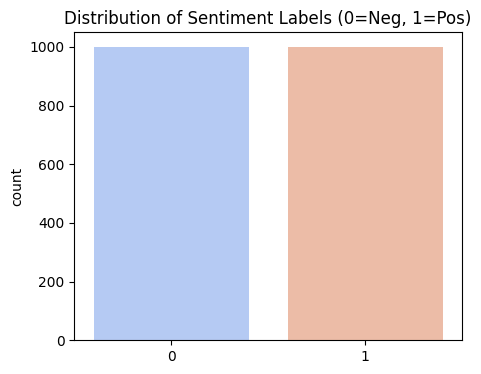

In [ ]:
drive.mount('/content/drive')
#  Load Dataset
data_path = "/content/drive/MyDrive/Colab Notebooks/NLP_2025/Transformers/txt_sentoken"

movie_data = load_files(data_path, categories=['pos', 'neg'])
texts, labels = movie_data.data, movie_data.target
texts = [t.decode('utf-8', errors='ignore') for t in texts]

print(f"Dataset Loaded: {len(texts)} reviews (Pos={sum(labels)}, Neg={len(labels)-sum(labels)})")

# Plot distribution of labels
plt.figure(figsize=(5,4))
sns.countplot(x=labels, palette='coolwarm')
plt.title("Distribution of Sentiment Labels (0=Neg, 1=Pos)")
plt.show()

In [ ]:
# Display few sample reviews
print("\n--- Sample Reviews ---")
for i in range(2):
    print(f"\nReview {i+1} ({'Positive' if labels[i]==1 else 'Negative'}):\n{texts[i][:300]}...")


--- Sample Reviews ---

Review 1 (Negative):
arnold schwarzenegger has been an icon for action enthusiasts , since the late 80's , but lately his films have been very sloppy and the one-liners are getting worse . 
it's hard seeing arnold as mr . freeze in batman and robin , especially when he says tons of ice jokes , but hey he got 15 million ...

Review 2 (Positive):
good films are hard to find these days . 
great films are beyond rare . 
proof of life , russell crowe's one-two punch of a deft kidnap and rescue thriller , is one of those rare gems . 
a taut drama laced with strong and subtle acting , an intelligent script , and masterful directing , together it ...


In [ ]:
#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

In [ ]:
#  Load Transformer


sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Other lightweight alternatives
#sentiment_model = pipeline("sentiment-analysis", model="sshleifer/tiny-distilbert-base-uncased-finetuned-sst-2-english")
#sentiment_model = pipeline("sentiment-analysis", model="distilroberta-base")


print("\nModel loaded successfully. Beginning predictions...\n")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0



Model loaded successfully. Beginning predictions...



You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Classification Report:

              precision    recall  f1-score   support

         neg       0.67      0.73      0.70       190
         pos       0.73      0.68      0.71       210

    accuracy                           0.70       400
   macro avg       0.70      0.70      0.70       400
weighted avg       0.70      0.70      0.70       400

Accuracy: 0.7025


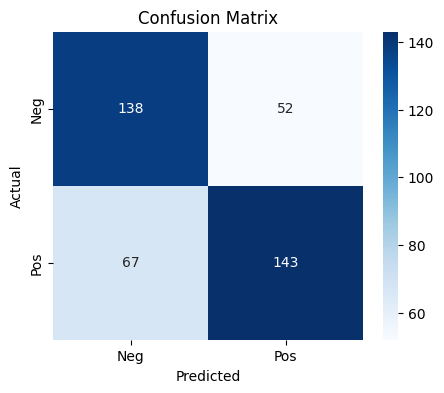

In [ ]:

#  Make Predictions

preds = []
for text in X_test:
    result = sentiment_model(text[:512])[0]  # limit to 512 tokens per review
    preds.append(1 if result['label'] == 'POSITIVE' else 0)


#  Evaluation

print("\nClassification Report:\n")
print(classification_report(y_test, preds, target_names=['neg', 'pos']))

acc = accuracy_score(y_test, preds)
print(f"Accuracy: {acc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()




In [ ]:
# Display Few Predictions

print("\n--- Sample Predictions ---")
for i in range(3):
    print(f"\nReview {i+1}:\n{texts[i][:200]}...")
    print(f"Actual: {'Positive' if y_test[i]==1 else 'Negative'}, Predicted: {'Positive' if preds[i]==1 else 'Negative'}")



--- Sample Predictions ---

Review 1:
arnold schwarzenegger has been an icon for action enthusiasts , since the late 80's , but lately his films have been very sloppy and the one-liners are getting worse . 
it's hard seeing arnold as mr ....
Actual: Positive, Predicted: Positive

Review 2:
good films are hard to find these days . 
great films are beyond rare . 
proof of life , russell crowe's one-two punch of a deft kidnap and rescue thriller , is one of those rare gems . 
a taut drama ...
Actual: Negative, Predicted: Positive

Review 3:
quaid stars as a man who has taken up the proffesion of dragonslayer after he feels he is betrayed by a dragon early in the movie . 
he runs into the last dragon in existence , and there is a genuinel...
Actual: Positive, Predicted: Negative
